# Homework 2

Name: Shanglin Jiang

GitHub Username: TODO — sjiang83-corgi

USC ID: 1967702034


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

predictors = ["AT", "V", "AP", "RH"]

## 1(a) Load the data

Use the first sheet only. The other sheets contain shuffled versions of the same dataset. Run this notebook with `notebook/` as the working directory.


In [2]:
data = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx", sheet_name=0, engine="openpyxl")
display(data.head())
print("Data shape:", data.shape)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Data shape: (9568, 5)


## 1(b)(i) Dataset dimensions and variable meanings

The dataset has 9,568 rows and 5 columns, each row containing hourly average figures taken from a combined-cycle power plant that was working at full load between 2006 and 2011.

The factors under consideration are AT, V, AP, and RH, where AT stands for ambient temperature, V for exhaust vacuum, AP for ambient pressure, and RH for relative humidity. The response is PE, which indicates the net electrical power output on an hourly basis.


In [3]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])
print("Predictors:", list(data.columns.drop("PE")))
print("Response: PE")


Rows: 9568
Columns: 5
Predictors: ['AT', 'V', 'AP', 'RH']
Response: PE


## 1(b)(ii) Pairwise scatterplots and findings

Figure 1 includes all four predictors and the response PE. Every off-diagonal panel compares two different variables; the diagonal panels show each variable against itself.


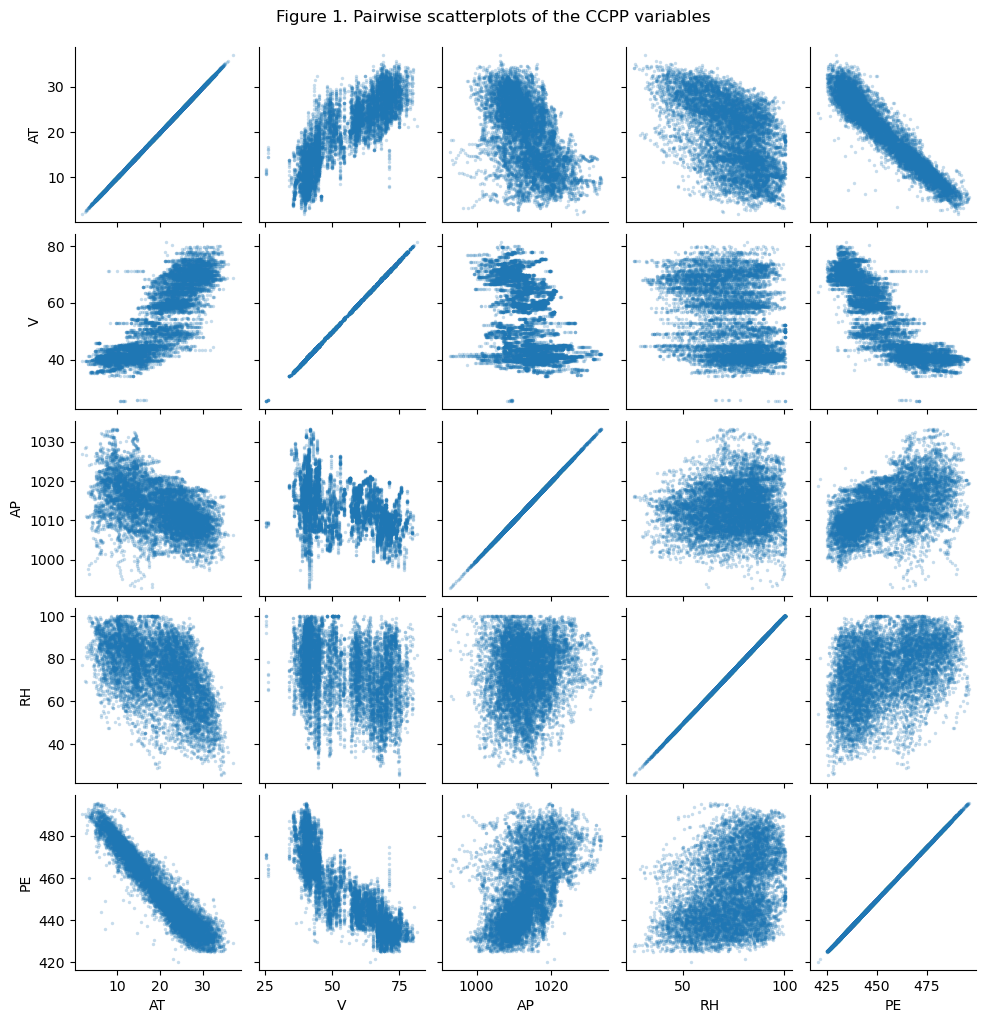

In [4]:
pair_grid = sns.pairplot(
    data,
    vars=["AT", "V", "AP", "RH", "PE"],
    kind="scatter",
    diag_kind=None,
    height=2,
    plot_kws={"s": 6, "alpha": 0.25, "linewidth": 0}
)
pair_grid.fig.suptitle("Figure 1. Pairwise scatterplots of the CCPP variables", y=1.02)
plt.show()


As AT increases, PE generally decreases, which is the most evident relationship in the graphs. V also has a negative relationship with PE, but the points are more scattered. AP and RH show only weak positive relationships with PE.

AT and V show a strong positive correlation; some of the plots also indicate curved patterns and clusters, which implies that nonlinear terms might be useful in describing the data. However, these relationships by themselves do not prove causation.


## 1(b)(iii) Descriptive statistics

The table gives the mean, median, range, Q1, Q3, and IQR for each variable, with these values rounded to three decimal places. The range is obtained by subtracting the minimum value from the maximum. Q1 and Q3 are the 25th and 75th percentiles respectively, and the IQR is calculated by subtracting Q1 from Q3.


In [5]:
q1 = data.quantile(0.25)
q3 = data.quantile(0.75)

summary_statistics = pd.DataFrame({
    "Mean": data.mean(),
    "Median": data.median(),
    "Range": data.max() - data.min(),
    "Q1": q1,
    "Q3": q3,
    "IQR": q3 - q1
})
summary_statistics.index.name = "Variable"

print("Table 1. Descriptive statistics")
display(summary_statistics.round(3))


Table 1. Descriptive statistics


,Mean,Median,Range,Q1,Q3,IQR
Variable,,,,,,
AT,19.651,20.345,35.30,13.510,25.72,12.210
V,54.306,52.080,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,74.60,63.328,84.83,21.502
PE,454.365,451.550,75.50,439.750,468.43,28.680


## 1(c) Simple linear regression and outliers

Fit one model at a time, using a significance level of 0.05. For each predictor, show the regression summary, draw a fitted line, and inspect potential outliers. An absolute internally studentized residual greater than 3 flags a point for inspection; it does not automatically justify removing it.

### AT

Fit PE using AT as the only predictor.

In [6]:
model_AT = smf.ols("PE ~ AT", data=data).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:17   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

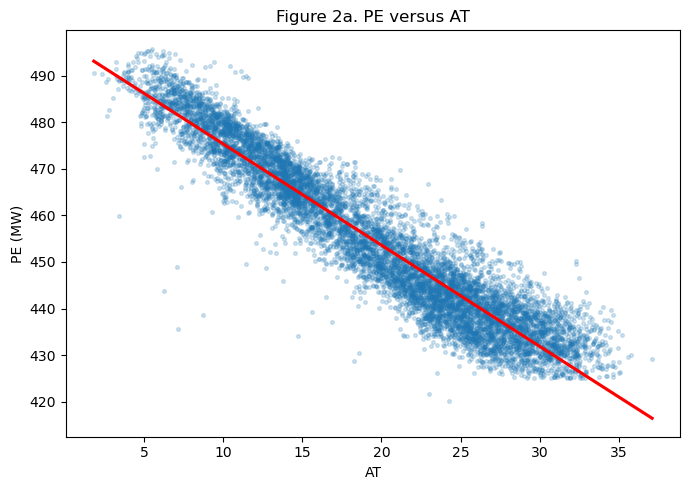

In [7]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=data,
    x="AT",
    y="PE",
    ci=None,
    scatter_kws={"s": 7, "alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Figure 2a. PE versus AT")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

In [8]:
# Check observations with large studentized residuals.
residuals_AT = model_AT.get_influence().resid_studentized_internal
outliers_AT = data[abs(residuals_AT) > 3]

print("Potential outliers for AT:", len(outliers_AT))
display(outliers_AT.head())

Potential outliers for AT: 42


Variable,AT,V,AP,RH,PE
202,21.19,42.48,1013.43,80.52,469.76
437,12.97,49.83,1008.69,91.49,452.07
464,26.35,49.50,1012.67,41.34,458.41
611,26.38,49.50,1012.82,37.19,457.81
786,10.40,40.43,1025.46,75.09,492.09


### V

Fit PE using V as the only predictor.

In [9]:
model_V = smf.ols("PE ~ V", data=data).fit()
print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.0

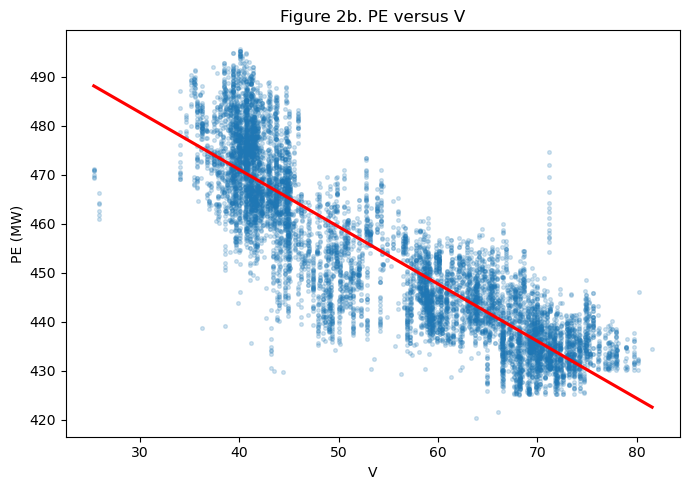

In [10]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=data,
    x="V",
    y="PE",
    ci=None,
    scatter_kws={"s": 7, "alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Figure 2b. PE versus V")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

In [11]:
# Check observations with large studentized residuals.
residuals_V = model_V.get_influence().resid_studentized_internal
outliers_V = data[abs(residuals_V) > 3]

print("Potential outliers for V:", len(outliers_V))
display(outliers_V.head())

Potential outliers for V: 33


Variable,AT,V,AP,RH,PE
182,11.75,71.14,1019.36,75.68,466.56
1376,23.56,42.67,1008.01,66.76,440.69
1438,15.61,38.52,1018.40,80.99,439.21
1709,8.13,71.14,1018.94,86.70,471.99
1773,13.95,71.14,1019.76,75.51,461.18


### AP

Fit PE using AP as the only predictor.

In [12]:
model_AP = smf.ols("PE ~ AP", data=data).fit()
print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.0

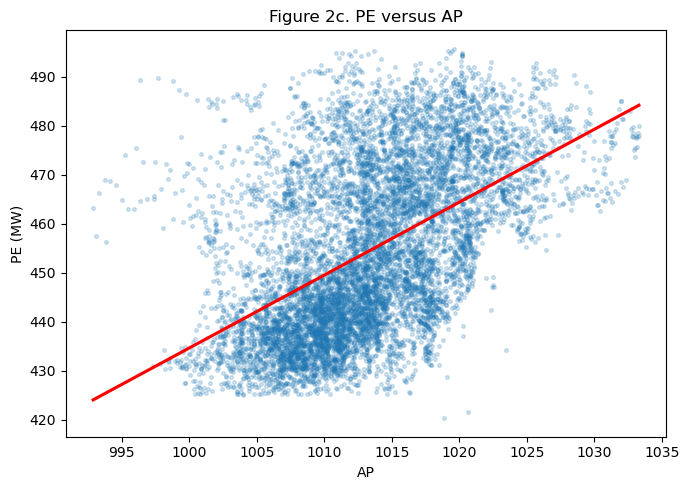

In [13]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=data,
    x="AP",
    y="PE",
    ci=None,
    scatter_kws={"s": 7, "alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Figure 2c. PE versus AP")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

In [14]:
# Check observations with large studentized residuals.
residuals_AP = model_AP.get_influence().resid_studentized_internal
outliers_AP = data[abs(residuals_AP) > 3]

print("Potential outliers for AP:", len(outliers_AP))
display(outliers_AP.head())

Potential outliers for AP: 29


Variable,AT,V,AP,RH,PE
618,5.71,41.31,1003.24,89.48,485.83
1091,11.01,42.02,995.24,98.62,473.96
1290,3.26,41.31,996.32,100.00,489.38
1662,4.73,41.31,999.77,93.44,486.60
1735,6.26,41.31,1002.04,87.54,485.57


### RH

Fit PE using RH as the only predictor.

In [15]:
model_RH = smf.ols("PE ~ RH", data=data).fit()
print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618      0.823    511.676      0.0

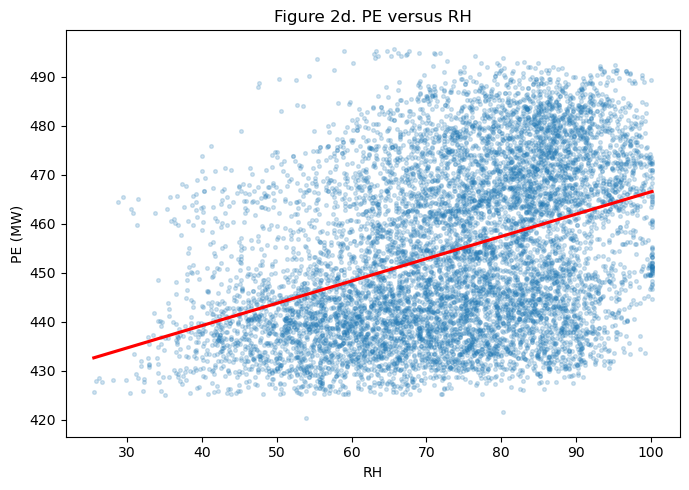

In [16]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=data,
    x="RH",
    y="PE",
    ci=None,
    scatter_kws={"s": 7, "alpha": 0.2},
    line_kws={"color": "red"}
)
plt.title("Figure 2d. PE versus RH")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

In [17]:
# Check observations with large studentized residuals.
residuals_RH = model_RH.get_influence().resid_studentized_internal
outliers_RH = data[abs(residuals_RH) > 3]

print("Potential outliers for RH:", len(outliers_RH))
display(outliers_RH.head())

Potential outliers for RH: 2


Variable,AT,V,AP,RH,PE
4719,6.17,40.07,1013.70,58.99,495.21
7900,6.58,40.07,1014.22,55.44,493.72


### Compare the four models

Keep the slopes in a small table for the coefficient comparison in 1(e). The full regression statistics are shown in the summaries above.

In [18]:
simple_results = pd.DataFrame({
    "Predictor": ["AT", "V", "AP", "RH"],
    "Slope": [model_AT.params["AT"], model_V.params["V"],
              model_AP.params["AP"], model_RH.params["RH"]]
}).set_index("Predictor")

display(simple_results)

,Slope
Predictor,
AT,-2.171320
V,-1.168135
AP,1.489872
RH,0.455650


Each of the four predictors has a significant relationship with PE at the 0.05 level; the slopes for AT and V are negative whereas those for AP and RH are positive. AT shows the best fit, with an R-squared value of 0.899, and the values for V, AP and RH are 0.757, 0.269 and 0.152 respectively. Even though all four slopes are significant, there are differences in their predictive power.

I identified 42 possible outliers for AT, 33 for V, 29 for AP, and 2 for RH on the basis of absolute studentized residuals exceeding 3. I have retained these observations since there is no evidence to suggest that they are the result of recording errors; their large residuals might be due to missing predictors or because the relationship in question cannot be adequately described by a straight line.

Certain p-values show as 0 since they are too small to be represented as numbers.

## 1(d) Multiple linear regression

Fit all four predictors together, keeping the original units.

In [19]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data=data).fit()
multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "Standard error": multiple_model.bse,
    "p-value": multiple_model.pvalues,
    "95% CI lower": multiple_model.conf_int()[0],
    "95% CI upper": multiple_model.conf_int()[1]
})
display(multiple_results)
print(f"R-squared: {multiple_model.rsquared:.4f}")
print("Significant predictors:", [x for x in predictors if multiple_model.pvalues[x] < 0.05])

,Coefficient,Standard error,p-value,95% CI lower,95% CI upper
Intercept,454.609274,9.748512,0.000000e+00,435.500123,473.718425
AT,-1.977513,0.015289,0.000000e+00,-2.007483,-1.947543
V,-0.233916,0.007282,4.375305e-215,-0.248191,-0.219642
AP,0.062083,0.009458,5.507109e-11,0.043543,0.080623
RH,-0.158054,0.004168,3.104584e-293,-0.166225,-0.149883


R-squared: 0.9287
Significant predictors: ['AT', 'V', 'AP', 'RH']


Since all four of the predictors have p-values less than 0.05, the null hypothesis H0: beta_j = 0 is rejected for each of them. The fitted model is:

\[ PE = 454.6093 - 1.9775AT - 0.2339V + 0.0621AP - 0.1581RH. \]

Each coefficient represents the relationship with PE when the other predictors are held constant. The model has an R-squared value of 0.9287, as compared to 0.8989 for the simple regression that used AT alone. The coefficients refer to the associations found in the data rather than demonstrating causal effects.

## 1(e) Compare regression coefficients

,Simple regression,Multiple regression
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


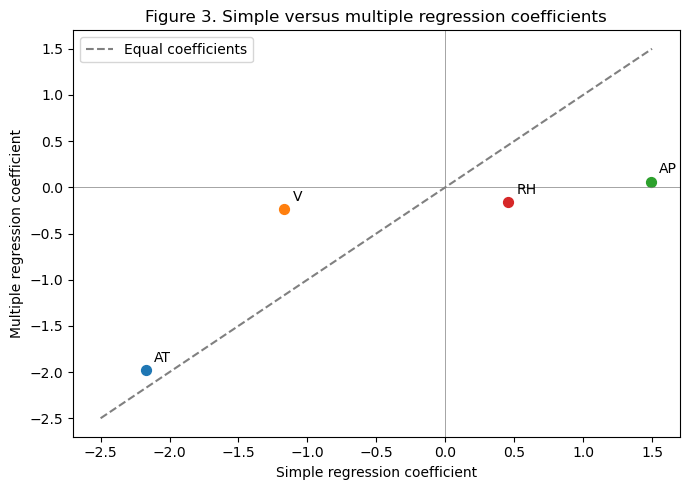

In [20]:
coefficient_comparison = pd.DataFrame({
    "Simple regression": simple_results["Slope"],
    "Multiple regression": multiple_model.params[predictors]
})
display(coefficient_comparison)
fig, ax = plt.subplots(figsize=(7, 5))
for feature in predictors:
    x, y = coefficient_comparison.loc[feature]
    ax.scatter(x, y, s=50)
    ax.annotate(feature, (x, y), xytext=(6, 6), textcoords="offset points")
limits = [-2.5, 1.5]
ax.plot(limits, limits, "--", color="gray", label="Equal coefficients")
ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set(xlabel="Simple regression coefficient", ylabel="Multiple regression coefficient",
       title="Figure 3. Simple versus multiple regression coefficients")
ax.legend()
plt.tight_layout()
plt.show()

The values of the coefficients are different when the predictors are all included; RH changes from having a positive coefficient in the simple regression to a negative one in the multiple regression, AP's coefficient becomes considerably smaller and V's coefficient moves nearer to zero.

Since the predictors are correlated, a simple regression will pick up on the relationships that are shared with the variables omitted from the model. When all four predictors are included, the estimated contribution of each one changes.

## 1(f) Cubic models and nonlinear associations

For numerical stability, I center each predictor before forming its square and cube. This is the same cubic model space as using raw powers, with a different coefficient parameterization. For each predictor, a nested F-test compares the cubic model with its straight-line model: H0 says that both nonlinear coefficients are zero.

In [21]:
centered_data = data.copy()
centered_data[predictors] = data[predictors] - data[predictors].mean()

### Cubic regression for AT

`I(AT ** 2)` adds the square and `I(AT ** 3)` adds the cube. The F-test checks whether these two terms together improve on a straight line.

In [22]:
cubic_AT = smf.ols("PE ~ AT + I(AT ** 2) + I(AT ** 3)", data=centered_data).fit()
print(cubic_AT.summary())

linear_AT = smf.ols("PE ~ AT", data=centered_data).fit()
f_test_AT = cubic_AT.compare_f_test(linear_AT)
print("Nonlinearity p-value:", f_test_AT[1])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.7081      0.074   6085.240      0.0

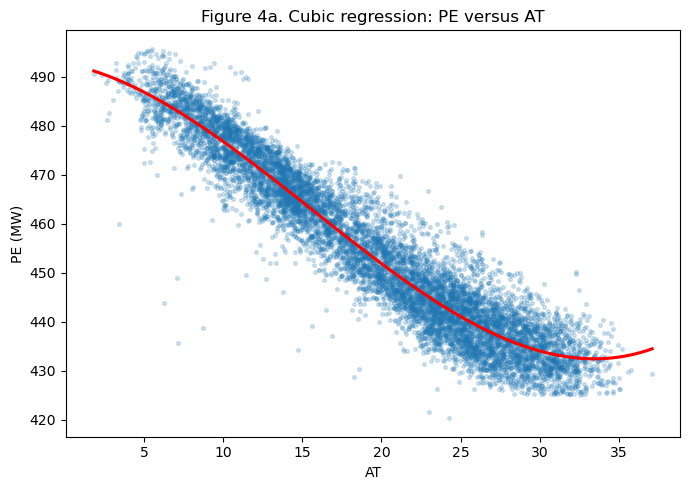

In [23]:
plt.figure(figsize=(7, 5))
sns.regplot(data=data, x="AT", y="PE", order=3, ci=None,
            scatter_kws={"s": 7, "alpha": 0.2},
            line_kws={"color": "red"})
plt.title("Figure 4a. Cubic regression: PE versus AT")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

### Cubic regression for V

`I(V ** 2)` adds the square and `I(V ** 3)` adds the cube. The F-test checks whether these two terms together improve on a straight line.

In [24]:
cubic_V = smf.ols("PE ~ V + I(V ** 2) + I(V ** 3)", data=centered_data).fit()
print(cubic_V.summary())

linear_V = smf.ols("PE ~ V", data=centered_data).fit()
f_test_V = cubic_V.compare_f_test(linear_V)
print("Nonlinearity p-value:", f_test_V[1])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    451.2137      0.144   3124.596      0.0

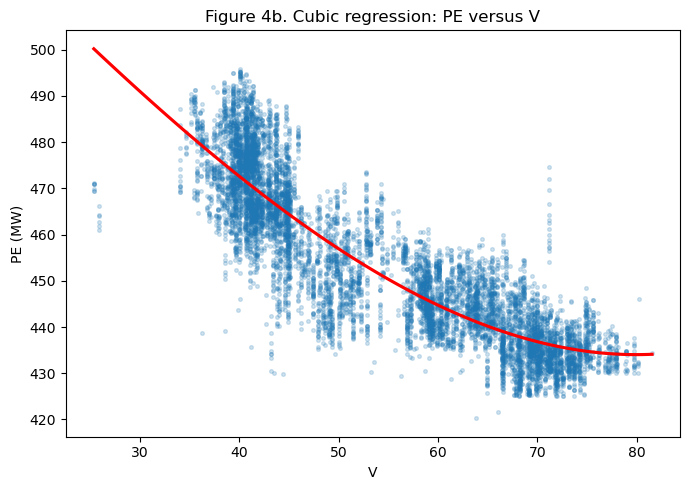

In [25]:
plt.figure(figsize=(7, 5))
sns.regplot(data=data, x="V", y="PE", order=3, ci=None,
            scatter_kws={"s": 7, "alpha": 0.2},
            line_kws={"color": "red"})
plt.title("Figure 4b. Cubic regression: PE versus V")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

### Cubic regression for AP

`I(AP ** 2)` adds the square and `I(AP ** 3)` adds the cube. The F-test checks whether these two terms together improve on a straight line.

In [26]:
cubic_AP = smf.ols("PE ~ AP + I(AP ** 2) + I(AP ** 3)", data=centered_data).fit()
print(cubic_AP.summary())

linear_AP = smf.ols("PE ~ AP", data=centered_data).fit()
f_test_AP = cubic_AP.compare_f_test(linear_AP)
print("Nonlinearity p-value:", f_test_AP[1])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.297
Method:                 Least Squares   F-statistic:                     1350.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -39032.
No. Observations:                9568   AIC:                         7.807e+04
Df Residuals:                    9564   BIC:                         7.810e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    453.0823      0.180   2520.290      0.0

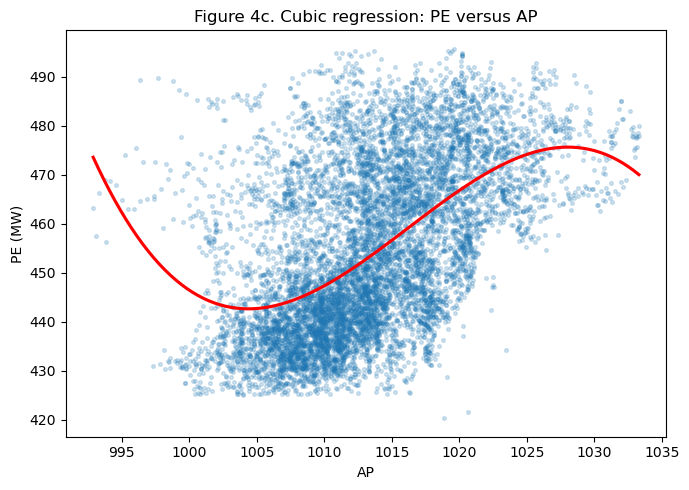

In [27]:
plt.figure(figsize=(7, 5))
sns.regplot(data=data, x="AP", y="PE", order=3, ci=None,
            scatter_kws={"s": 7, "alpha": 0.2},
            line_kws={"color": "red"})
plt.title("Figure 4c. Cubic regression: PE versus AP")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

### Cubic regression for RH

`I(RH ** 2)` adds the square and `I(RH ** 3)` adds the cube. The F-test checks whether these two terms together improve on a straight line.

In [28]:
cubic_RH = smf.ols("PE ~ RH + I(RH ** 2) + I(RH ** 3)", data=centered_data).fit()
print(cubic_RH.summary())

linear_RH = smf.ols("PE ~ RH", data=centered_data).fit()
f_test_RH = cubic_RH.compare_f_test(linear_RH)
print("Nonlinearity p-value:", f_test_RH[1])

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.4430      0.219   2076.903      0.0

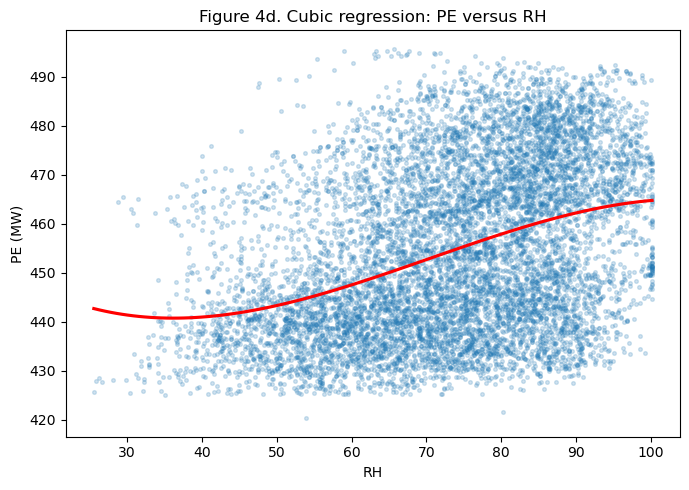

In [29]:
plt.figure(figsize=(7, 5))
sns.regplot(data=data, x="RH", y="PE", order=3, ci=None,
            scatter_kws={"s": 7, "alpha": 0.2},
            line_kws={"color": "red"})
plt.title("Figure 4d. Cubic regression: PE versus RH")
plt.ylabel("PE (MW)")
plt.tight_layout()
plt.show()

The joint tests above assess whether the square and cube improve on a straight line. A p-value below 0.05 is evidence of a nonlinear association. The R-squared comparison shows the size of the improvement; with this many observations, even a small improvement can be statistically significant.

All four joint tests reject the linear-only model. AT, V, and AP have extremely small p-values; RH also shows evidence of nonlinearity (p = 0.000038), although its R-squared only increases from 0.1519 to 0.1537. RH's squared term alone is not significant (p = 0.101), but its cubic term is (p = 0.0000144).

## 1(g) Pairwise interactions

Include all four main effects and all six distinct pairwise interactions. Predictors are centered to make the fit better conditioned. Interaction coefficients describe how a predictor's slope changes with another predictor.

In [30]:
# A colon adds the product of two predictors, such as AT * V.
interaction_formula = (
    "PE ~ AT + V + AP + RH"
    " + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
)
interaction_model = smf.ols(interaction_formula, data=centered_data).fit()
print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:18   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    452.6946      0.075   6074.393      0.0

In [31]:
interaction_pvalues = interaction_model.pvalues[
    ["AT:V", "AT:AP", "AT:RH", "V:AP", "V:RH", "AP:RH"]
]
print("Interaction p-values:")
print(interaction_pvalues)
print("Significant interactions:")
print(interaction_pvalues[interaction_pvalues < 0.05])

Interaction p-values:
AT:V     3.333358e-117
AT:AP     4.520509e-01
AT:RH     1.216944e-10
V:AP      2.877026e-07
V:RH      8.619366e-02
AP:RH     3.360557e-02
dtype: float64
Significant interactions:
AT:V     3.333358e-117
AT:RH     1.216944e-10
V:AP      2.877026e-07
AP:RH     3.360557e-02
dtype: float64


The model has all four main effects and six pairwise interactions; the predictors have been centred in order to avoid numerical problems, and each interaction enables the slope of one predictor to vary according to the value of another predictor.

AT:V, AT:RH, V:AP, and AP:RH show significance at the 0.05 level, while AT:AP and V:RH are not significant, their p-values being 0.452 and 0.086 respectively. Although these tests take into account the other terms in the model, they do not include a multiple-testing correction. The R-squared value for the model is 0.9363.

## 1(h) Improve the regression model

For training I used 70% of the data and for testing 30%, the random_state being set at 42; both models have the same data split. The centreing means and the selection of terms were calculated using only the training data.

### Split the data and fit the baseline

In [32]:
train_data, test_data = train_test_split(data, test_size=0.30, random_state=42)
print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

baseline_model = smf.ols("PE ~ AT + V + AP + RH", data=train_data).fit()

training_means = train_data[predictors].mean()
train_centered = train_data.copy()
test_centered = test_data.copy()
train_centered[predictors] = train_data[predictors] - training_means
test_centered[predictors] = test_data[predictors] - training_means

Training rows: 6697
Test rows: 2871


### Add all squares and pairwise interactions

In [33]:
full_formula = (
    "PE ~ AT + V + AP + RH"
    " + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
    " + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH"
)
full_quadratic_model = smf.ols(full_formula, data=train_centered).fit()
print(full_quadratic_model.pvalues.sort_values(ascending=False))

V:RH           8.673824e-01
I(V ** 2)      6.998020e-01
V:AP           3.811800e-01
AT:AP          1.966307e-01
AT:V           3.195237e-03
AT:RH          3.056335e-03
AP:RH          2.937919e-04
I(AT ** 2)     5.017196e-07
I(AP ** 2)     8.522142e-09
I(RH ** 2)     1.395087e-09
AP             1.165230e-22
RH            4.244793e-126
V             2.029704e-215
Intercept      0.000000e+00
AT             0.000000e+00
dtype: float64


V:RH has the largest p-value (0.867), so remove it and refit.

In [34]:
formula_step1 = full_formula + " - V:RH"
model_step1 = smf.ols(formula_step1, data=train_centered).fit()
print(model_step1.pvalues.sort_values(ascending=False))

I(V ** 2)      6.077328e-01
V:AP           3.397443e-01
AT:AP          1.983518e-01
AP:RH          2.074300e-04
AT:V           5.938202e-05
AT:RH          1.499480e-08
I(AP ** 2)     7.708529e-09
I(AT ** 2)     2.120525e-10
I(RH ** 2)     4.135297e-12
AP             1.171826e-22
RH            1.363290e-126
V             1.594007e-215
Intercept      0.000000e+00
AT             0.000000e+00
dtype: float64


After refitting, V squared has the largest p-value (0.608). Remove that square while keeping V.

In [35]:
formula_step2 = formula_step1 + " - I(V ** 2)"
model_step2 = smf.ols(formula_step2, data=train_centered).fit()
print(model_step2.pvalues.sort_values(ascending=False))

V:AP           3.578255e-01
AT:AP          1.845414e-01
AP:RH          1.905694e-04
AT:V           3.433734e-08
AT:RH          8.337728e-09
I(AP ** 2)     7.235847e-09
I(RH ** 2)     2.666222e-12
I(AT ** 2)     2.406817e-13
AP             5.069527e-24
RH            1.467789e-126
V             4.494136e-220
Intercept      0.000000e+00
AT             0.000000e+00
dtype: float64


V:AP now has the largest p-value (0.358). Remove it and refit. All remaining terms have p-values below 0.05, so stop. If the split or data changes, these decisions should be checked again.

In [36]:
reduced_formula = formula_step2 + " - V:AP"
reduced_model = smf.ols(reduced_formula, data=train_centered).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     9258.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:06:19   Log-Likelihood:                -19161.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6685   BIC:                         3.843e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    453.2275      0.099   4582.006      0.0

### Calculate train and test MSE

In [37]:
baseline_train_mse = mean_squared_error(train_data["PE"], baseline_model.predict(train_data))
baseline_test_mse = mean_squared_error(test_data["PE"], baseline_model.predict(test_data))

In [38]:
full_train_mse = mean_squared_error(train_data["PE"], full_quadratic_model.predict(train_centered))
full_test_mse = mean_squared_error(test_data["PE"], full_quadratic_model.predict(test_centered))

In [39]:
reduced_train_mse = mean_squared_error(train_data["PE"], reduced_model.predict(train_centered))
reduced_test_mse = mean_squared_error(test_data["PE"], reduced_model.predict(test_centered))

In [40]:
regression_results = pd.DataFrame({
    "Model": ["All-predictor linear", "Full quadratic + interactions", "Reduced quadratic + interactions"],
    "Train MSE": [baseline_train_mse, full_train_mse, reduced_train_mse],
    "Test MSE": [baseline_test_mse, full_test_mse, reduced_test_mse]
}).set_index("Model")
display(regression_results)

,Train MSE,Test MSE
Model,,
All-predictor linear,20.580840,21.239857
Full quadratic + interactions,17.887800,18.647312
Reduced quadratic + interactions,17.890843,18.660040


I began by removing V:RH, followed by V squared, and then V:AP, starting with the main effects, the squares, and the pairwise interactions. After each of these removals I refitted the model. All of the remaining terms had p-values less than 0.05 and I retained the main effects that were required by the remaining squares and interactions.

The baseline model has training and test mean squared errors of 20.5808 and 21.2399 respectively, while the reduced model brings them down to 17.8908 and 18.6600. The test mean squared error of the reduced model is approximately 12.1 per cent lower than that of the baseline.

The complete model has a very slightly smaller test MSE of 18.6473; it therefore becomes simpler when the insignificant terms are removed, even though there is a small increase in test error.

## 1(i) KNN regression with raw and normalized features

Use the same split as 1(h) and uniform neighbor weights. Here, normalization means standardization to zero mean and unit variance; the scaler is fitted on the training data only. For each version, compare k = 1,...,100. The selected k minimizes test MSE for this assignment. Because the test set is used for tuning, its minimum error is not an independent final estimate of generalization performance.

### Prepare the raw and standardized features

In [41]:
X_train = train_data[predictors].to_numpy()
X_test = test_data[predictors].to_numpy()
y_train = train_data["PE"].to_numpy()
y_test = test_data["PE"].to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
k_values = np.arange(1, 101)

### Raw features

Try each k, save the train and test errors, and choose the k with the lowest test MSE.

In [42]:
raw_train_errors = []
raw_test_errors = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=int(k), weights="uniform", metric="euclidean")
    knn.fit(X_train, y_train)

    train_predictions = knn.predict(X_train)
    test_predictions = knn.predict(X_test)
    raw_train_errors.append(mean_squared_error(y_train, train_predictions))
    raw_test_errors.append(mean_squared_error(y_test, test_predictions))

raw_best_index = np.argmin(raw_test_errors)
raw_best_k = k_values[raw_best_index]
print("Best k:", raw_best_k)
print("Best test MSE:", raw_test_errors[raw_best_index])

Best k: 5
Best test MSE: 15.726819842563568


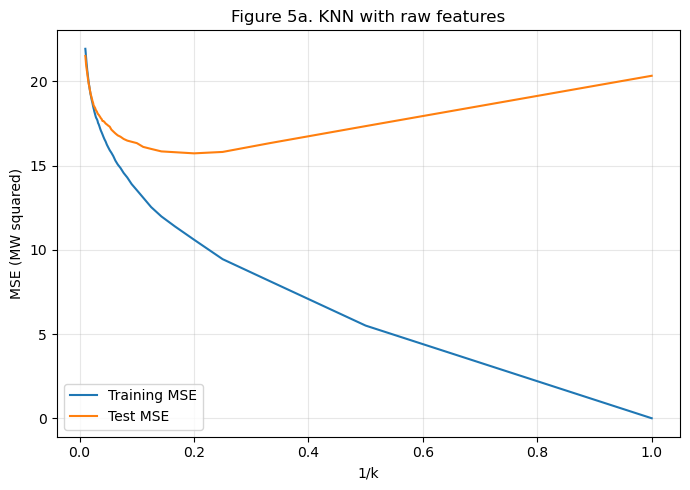

In [43]:
plt.figure(figsize=(7, 5))
plt.plot(1 / k_values, raw_train_errors, label="Training MSE")
plt.plot(1 / k_values, raw_test_errors, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE (MW squared)")
plt.title("Figure 5a. KNN with raw features")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Standardized features

Try each k, save the train and test errors, and choose the k with the lowest test MSE.

In [44]:
scaled_train_errors = []
scaled_test_errors = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=int(k), weights="uniform", metric="euclidean")
    knn.fit(X_train_scaled, y_train)

    train_predictions = knn.predict(X_train_scaled)
    test_predictions = knn.predict(X_test_scaled)
    scaled_train_errors.append(mean_squared_error(y_train, train_predictions))
    scaled_test_errors.append(mean_squared_error(y_test, test_predictions))

scaled_best_index = np.argmin(scaled_test_errors)
scaled_best_k = k_values[scaled_best_index]
print("Best k:", scaled_best_k)
print("Best test MSE:", scaled_test_errors[scaled_best_index])

Best k: 4
Best test MSE: 14.305669422675024


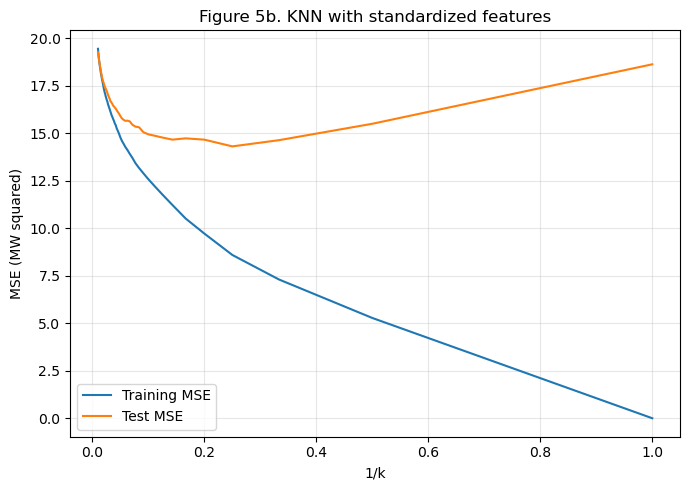

In [45]:
plt.figure(figsize=(7, 5))
plt.plot(1 / k_values, scaled_train_errors, label="Training MSE")
plt.plot(1 / k_values, scaled_test_errors, label="Test MSE")
plt.xlabel("1/k")
plt.ylabel("MSE (MW squared)")
plt.title("Figure 5b. KNN with standardized features")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
knn_results = pd.DataFrame({
    "Features": ["Raw", "Standardized"],
    "Best k": [raw_best_k, scaled_best_k],
    "Train MSE": [raw_train_errors[raw_best_index], scaled_train_errors[scaled_best_index]],
    "Test MSE": [raw_test_errors[raw_best_index], scaled_test_errors[scaled_best_index]]
}).set_index("Features")
display(knn_results)

,Best k,Train MSE,Test MSE
Features,,,
Raw,5,10.600769,15.726820
Standardized,4,8.591433,14.305669


When k equals 1 the training error is very low since each training item can act as its own nearest neighbour. Raising the value of k results in smoother predictions. This may be helpful at first, but higher values can lead to underfitting.

The value of k was chosen using test MSE, and therefore the minimum value given here is the result of a tuning process. It must not be regarded as a separate estimate of the performance on new data.

## 1(j) Compare KNN and regression

Compare models on the same 30% test subset. “Regression” below includes the polynomial and interaction models, which remain linear in their coefficients.

In [47]:
print("Regression models, ordered by test MSE:")
display(regression_results.sort_values("Test MSE"))

print("KNN models, ordered by test MSE:")
display(knn_results.sort_values("Test MSE"))

best_regression_error = regression_results["Test MSE"].min()
best_knn_error = knn_results["Test MSE"].min()
print("Best regression test MSE:", best_regression_error)
print("Best KNN test MSE:", best_knn_error)
print("MSE difference (regression - KNN):", best_regression_error - best_knn_error)

Regression models, ordered by test MSE:


,Train MSE,Test MSE
Model,,
Full quadratic + interactions,17.887800,18.647312
Reduced quadratic + interactions,17.890843,18.660040
All-predictor linear,20.580840,21.239857


KNN models, ordered by test MSE:


,Best k,Train MSE,Test MSE
Features,,,
Standardized,4,8.591433,14.305669
Raw,5,10.600769,15.726820


Best regression test MSE: 18.647312478602775
Best KNN test MSE: 14.305669422675024
MSE difference (regression - KNN): 4.341643055927751


Of all the regression models, the one that includes quadratic and interaction terms has the smallest test MSE, which is 18.6473; the standardized KNN using k=4 does even better on the same test set, achieving an MSE of 14.3057. This represents a reduction of 4.3416, or approximately 23.3%.

On the basis of this comparison I would go for KNN when it comes to prediction since it is able to capture local patterns, whereas the regression model provides a concise equation with coefficients that are simpler to interpret. The results here depend on the way the data has been split and on the models that have been tested. Because the test set was also employed in selecting k, it would be necessary to include a further validation stage before assessing the final choice on a separate test set.

## 2. ISLR 2.4.1

(a)
Because there are many observations and only a small number of predictors, the risk of overfitting is very low and so the cost of flexibility (in the form of high variance) is small. By using a flexible method, the abundant data can be made use of to fit a highly complex model close to the true f, thus reducing bias and resulting in a lower test error.

(b)
When the number of dimensions is high and the number of observations is small, a flexible method has very high variance and will badly overfit (this is known as the curse of dimensionality) because there is simply not enough data to support a complicated fit; a more restricted method, for example linear regression, will generalize far better.

(c)
A method that is inflexible (for example, linear regression) is very limited in the kinds of relationships it can represent and will have a large bias since it is unable to capture the non-linear structure; on the other hand, a flexible method can approximate the curved function f much more accurately.

(d)
When the irreducible error is the main factor, there is very little signal available for extraction compared to the noise. A flexible approach will follow the noise and increase the variance without making any real reduction in bias. It is therefore advisable to accept a certain amount of bias in order to achieve a large decrease in variance, and in this case a simple and restricted method should be chosen.

## 3. ISLR 2.4.7

（a）
In summary, the six distances are 3, 2, 3.16, 2.24, 1.41, and 1.73, respectively. Observation 5 is the closest to the test point, followed by Observation 6, then Observation 2, Observation 4, Observation 1, and finally Observation 3, which is the farthest.

(b) With K = 1, the prediction is Green.
K = 1 uses only the single nearest neighbor. The closest observation to the test point is Obs. 5 (distance 1.41), whose response is Green. Therefore we predict Green.

(c) With K = 3, the prediction is Red.
The three nearest neighbors are:

Obs. 5 (distance 1.41) — Green
Obs. 6 (distance 1.73) — Red
Obs. 2 (distance 2) — Red

（d）
A small value of K makes KNN more flexible since the decision boundary can adapt locally and has a low bias (even though it has a high variance), enabling it to approximate a highly non-linear Bayes decision boundary. A large K results in a smoother, almost linear boundary with high bias and would therefore be too simplistic for a non-linear boundary. For these reasons a smaller K is preferred.


## References

- Assignment handout (provided by the instructor).
- Dataset documentation: `../data/CCPP/Readme.txt`.
- UCI Combined Cycle Power Plant: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant
